In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ratings = pd.read_csv("../data/raw/ratings.csv")
movies = pd.read_csv("../data/raw/movies.csv")


In [7]:
ratings.head()

movies.head()

,Film,Genre,Lead Studio,Audience score %,Profitability,Rotten Tomatoes %,Worldwide Gross,Year
0,Zack and Miri Make a Porno,Romance,The Weinstein Company,70,1.747542,64,$41.94,2008
1,Youth in Revolt,Comedy,The Weinstein Company,52,1.090000,68,$19.62,2010
2,You Will Meet a Tall Dark Stranger,Comedy,Independent,35,1.211818,43,$26.66,2010
3,When in Rome,Comedy,Disney,44,0.000000,15,$43.04,2010
4,What Happens in Vegas,Comedy,Fox,72,6.267647,28,$219.37,2008


In [8]:
ratings.isnull().sum()

movies.isnull().sum()

Film                 0
Genre                0
Lead Studio          0
Audience score %     0
Profitability        0
Rotten Tomatoes %    0
Worldwide Gross      0
Year                 0
dtype: int64

In [9]:
movies = movies.dropna()
ratings = ratings.dropna()

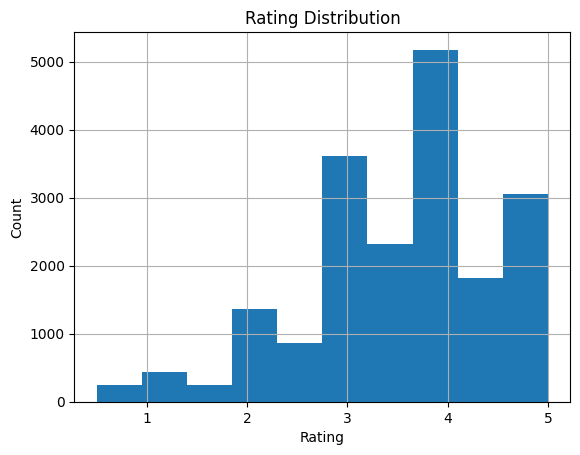

In [12]:
ratings["rating"].hist()

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")

plt.savefig("../reports/figures/rating_distribution.png")

plt.show()

In [18]:
ratings = pd.read_csv("../data/raw/ratings.csv")

ratings.columns.tolist()

['user', 'movie', 'rating', 'timestamp']

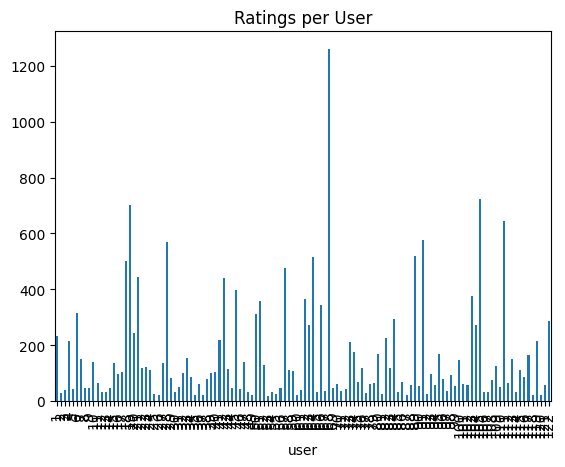

In [20]:
ratings.groupby("user").size().plot(kind="bar")

plt.title("Ratings per User")

plt.savefig("../reports/figures/user_ratings.png")

plt.show()

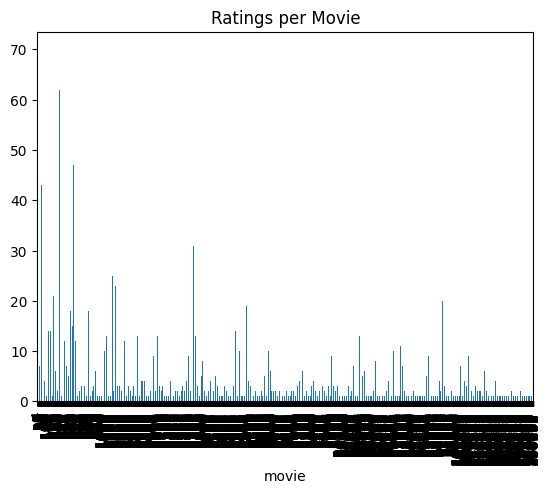

In [21]:
ratings.groupby("movie").size().plot(kind="bar")

plt.title("Ratings per Movie")

plt.savefig("../reports/figures/movie_ratings.png")

plt.show()

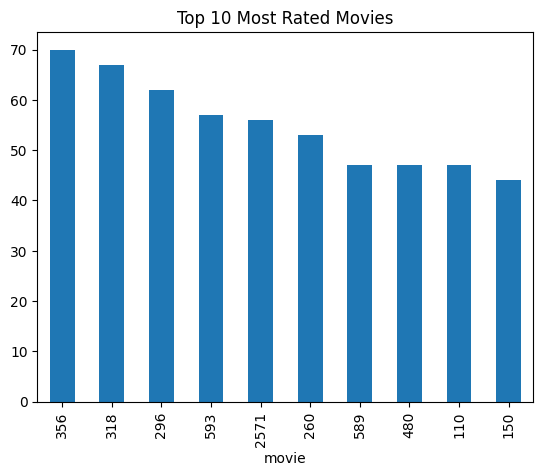

In [22]:
ratings["movie"].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Most Rated Movies")

plt.savefig("../reports/figures/top10_movies.png")

plt.show()

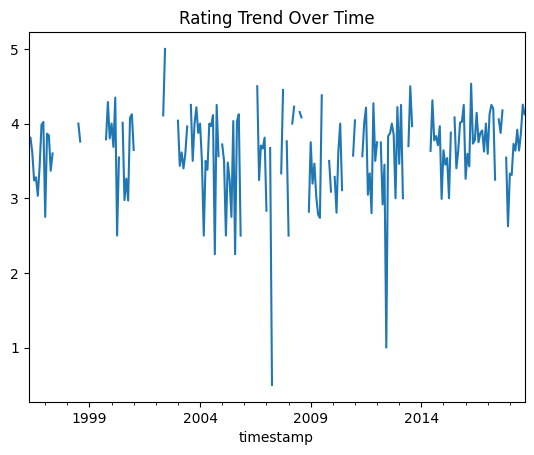

In [23]:
ratings['timestamp'] = pd.to_datetime(
    ratings['timestamp'],
    unit='s'
)

ratings.set_index(
    'timestamp'
)['rating'].resample(
    'M'
).mean().plot()

plt.title("Rating Trend Over Time")

plt.savefig(
"../reports/figures/rating_trend.png"
)

plt.show()

In [24]:
movies.columns

Index(['Film', 'Genre', 'Lead Studio', 'Audience score %', 'Profitability',
       'Rotten Tomatoes %', 'Worldwide Gross', 'Year'],
      dtype='object')

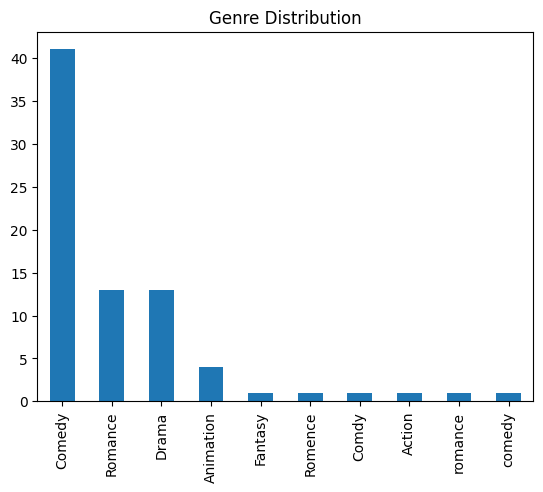

In [26]:
genres = movies['Genre'].str.split(',')

all_genres = []

for g in genres:
    all_genres.extend(g)

pd.Series(
    all_genres
).value_counts().plot(
    kind='bar'
)

plt.title(
    "Genre Distribution"
)

plt.savefig(
    "../reports/figures/genre_distribution.png"
)

plt.show()

In [27]:
ratings.to_csv(
'../data/processed/ratings_clean.csv',
index=False
)

movies.to_csv(
'../data/processed/movies_clean.csv',
index=False
)

In [28]:
import os

os.listdir("../data/processed")

['movies_clean.csv', 'ratings_clean.csv']